In [6]:
!pip install ultralytics opencv-python matplotlib pandas

In [7]:
import os
import shutil
import cv2
import xml.etree.ElementTree as ET
from glob import glob
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

%matplotlib inline

In [24]:
import os
import shutil
import xml.etree.ElementTree as ET
import pandas as pd
from glob import glob

dataset_paths = [
    r'D:\faculta an 3\an3 sbc\proiect\Automatic headlight dimming control.v1i.tensorflow', 
    r'D:\faculta an 3\an3 sbc\proiect\Automatic headlight dimming control.v2i.tensorflow'
]

output_dir = 'final_combined_dataset'

def convert_bbox(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

found_classes = set()

for ds_path in dataset_paths:
    if not os.path.exists(ds_path): continue
    
    csv_files = glob(os.path.join(ds_path, '**', '*.csv'), recursive=True)
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            if 'class' in df.columns:
                unique_classes = df['class'].unique()
                for c in unique_classes: found_classes.add(str(c))
        except: pass
        
    xml_files = glob(os.path.join(ds_path, '**', '*.xml'), recursive=True)
    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            for obj in root.iter('object'):
                found_classes.add(obj.find('name').text)
        except: pass

classes = sorted(list(found_classes))
if len(classes) == 0:
    classes = ['Car', 'Truck', 'Bus', 'Motorcycle', 'Pedestrian']

class_to_id = {name: i for i, name in enumerate(classes)}

subsets = ['train', 'valid', 'test']
if os.path.exists(output_dir): shutil.rmtree(output_dir)

for subset in subsets:
    os.makedirs(os.path.join(output_dir, subset, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, subset, 'labels'), exist_ok=True)

global_idx = 0

for ds_path in dataset_paths:
    if not os.path.exists(ds_path): continue
    
    for subset_name in subsets:
        search_path = os.path.join(ds_path, subset_name)
        if not os.path.exists(search_path): continue
        
        csv_path = os.path.join(search_path, '_annotations.csv')
        csv_data = None
        if os.path.exists(csv_path):
            try:
                csv_data = pd.read_csv(csv_path)
                csv_grouped = csv_data.groupby('filename')
            except: pass

        images = glob(os.path.join(search_path, '*.jpg')) + glob(os.path.join(search_path, '*.png'))
        
        for img_path in images:
            filename = os.path.basename(img_path)
            file_root, _ = os.path.splitext(filename)
            
            new_img_name = f"data_{global_idx}.jpg"
            new_label_name = f"data_{global_idx}.txt"
            
            shutil.copy(img_path, os.path.join(output_dir, subset_name, 'images', new_img_name))
            
            label_path_out = os.path.join(output_dir, subset_name, 'labels', new_label_name)
            has_labels = False

            if csv_data is not None and filename in csv_grouped.groups:
                rows = csv_grouped.get_group(filename)
                with open(label_path_out, 'w') as f_out:
                    for _, row in rows.iterrows():
                        c_name = str(row['class'])
                        if c_name not in class_to_id: continue
                        
                        cid = class_to_id[c_name]
                        w_img = int(row['width'])
                        h_img = int(row['height'])
                        
                        b = (float(row['xmin']), float(row['xmax']), 
                             float(row['ymin']), float(row['ymax']))
                        
                        bb = convert_bbox((w_img, h_img), b)
                        f_out.write(f"{cid} {bb[0]} {bb[1]} {bb[2]} {bb[3]}\n")
                has_labels = True

            elif not has_labels:
                xml_path = os.path.join(search_path, file_root + '.xml')
                if os.path.exists(xml_path):
                    tree = ET.parse(xml_path)
                    root = tree.getroot()
                    size = root.find('size')
                    w = int(size.find('width').text)
                    h = int(size.find('height').text)
                    
                    with open(label_path_out, 'w') as f_out:
                        for obj in root.iter('object'):
                            c_name = obj.find('name').text
                            if c_name in class_to_id:
                                cid = class_to_id[c_name]
                                xmlbox = obj.find('bndbox')
                                b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                                     float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
                                bb = convert_bbox((w, h), b)
                                f_out.write(f"{cid} {bb[0]} {bb[1]} {bb[2]} {bb[3]}\n")
                    has_labels = True
            
            global_idx += 1

base_path = os.path.abspath(output_dir)
print(base_path)
print(classes)

C:\Users\Luci\final_combined_dataset
['Stopdriving', 'headlight', 'novehicle', 'signal', 'stopdriving', 'streetlight', 'taillight']


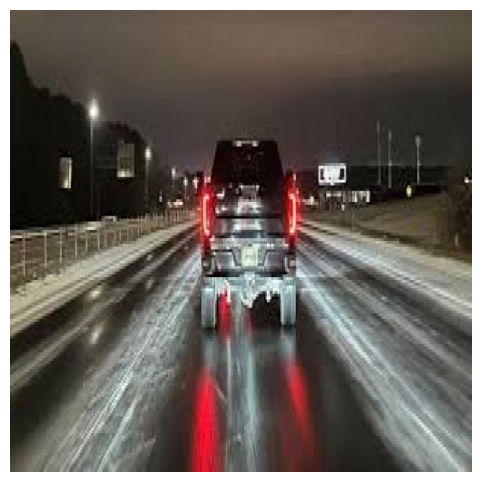

In [25]:
check_folder = os.path.join(base_path, 'train', 'images')
img_files = glob(os.path.join(check_folder, '*.jpg')) + glob(os.path.join(check_folder, '*.png'))

if len(img_files) > 0:
    img_path = random.choice(img_files)
    img = cv2.imread(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("Folderul este gol")

In [26]:
safe_path = base_path.replace('\\', '/')

yaml_content = f"""
path: {safe_path}
train: train/images
val: valid/images
test: test/images

nc: {len(classes)}
names: {classes}
"""

yaml_path = 'combined_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

In [27]:
model = YOLO('yolov8n.pt')

In [28]:
results = model.train(data='combined_data.yaml', epochs=25, imgsz=640, plots=True)

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.227  Python-3.13.5 torch-2.9.0+cpu CPU (Intel Core i5-7200U 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=combined_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize

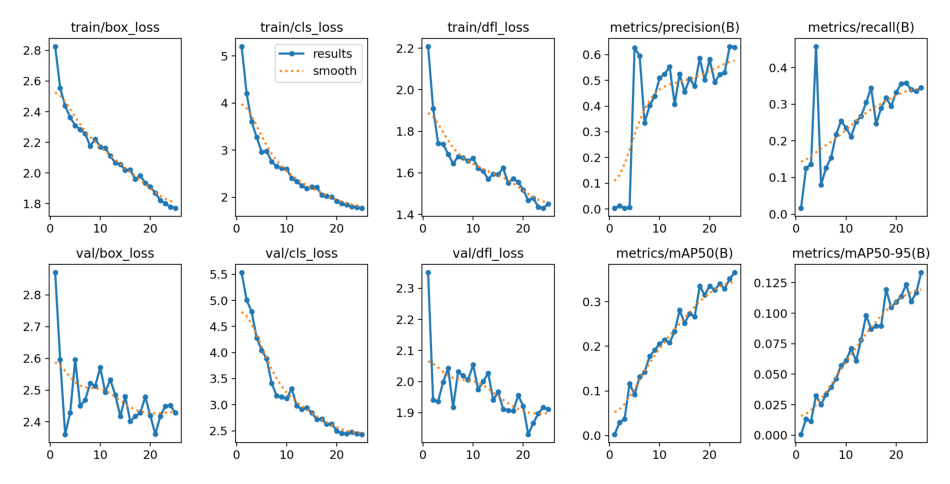

In [29]:
results_dir = model.trainer.save_dir
results_png = os.path.join(results_dir, 'results.png')

if os.path.exists(results_png):
    img = cv2.imread(results_png)
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [30]:
metrics = model.val()
print(metrics.box.map50)
print(metrics.box.map)

Ultralytics 8.3.227  Python-3.13.5 torch-2.9.0+cpu CPU (Intel Core i5-7200U 2.50GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 130.121.7 MB/s, size: 24.3 KB)
val: Scanning C:\Users\Luci\final_combined_dataset\valid\labels.cache... 84 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 84/84 107.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 0.5it/s 13.2s3.0s
                   all         84        190      0.628      0.345      0.366      0.134
           Stopdriving          2          2          1          0          0          0
             headlight         52         74      0.607      0.514      0.553        0.2
             novehicle         22         22      0.403      0.273      0.285      0.157
           streetlight         36         60      0.484        0.6      0.552      0.173
             taillight         


image 1/42 C:\Users\Luci\final_combined_dataset\test\images\data_194.jpg: 640x640 1 headlight, 456.9ms
image 2/42 C:\Users\Luci\final_combined_dataset\test\images\data_195.jpg: 640x640 1 novehicle, 246.7ms
image 3/42 C:\Users\Luci\final_combined_dataset\test\images\data_196.jpg: 640x640 1 novehicle, 1 streetlight, 207.6ms
image 4/42 C:\Users\Luci\final_combined_dataset\test\images\data_197.jpg: 640x640 1 headlight, 2 streetlights, 235.8ms
image 5/42 C:\Users\Luci\final_combined_dataset\test\images\data_198.jpg: 640x640 (no detections), 191.1ms
image 6/42 C:\Users\Luci\final_combined_dataset\test\images\data_199.jpg: 640x640 (no detections), 165.2ms
image 7/42 C:\Users\Luci\final_combined_dataset\test\images\data_200.jpg: 640x640 1 headlight, 155.4ms
image 8/42 C:\Users\Luci\final_combined_dataset\test\images\data_201.jpg: 640x640 2 headlights, 155.9ms
image 9/42 C:\Users\Luci\final_combined_dataset\test\images\data_202.jpg: 640x640 1 headlight, 3 streetlights, 164.9ms
image 10/42 C:\U

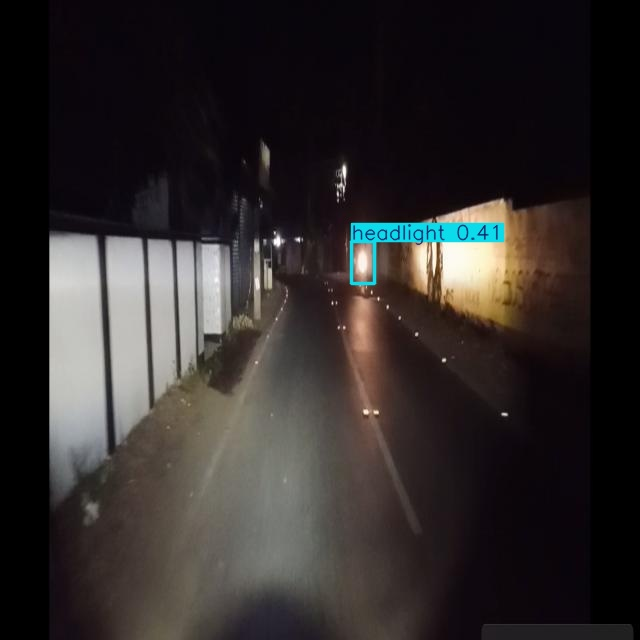

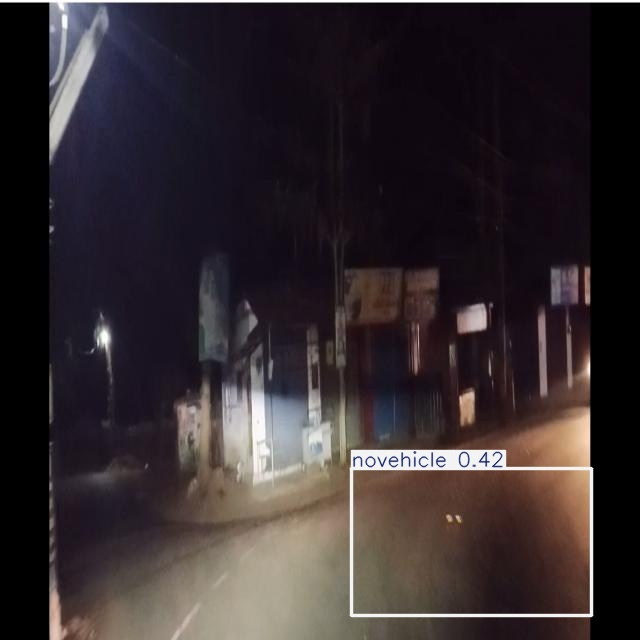

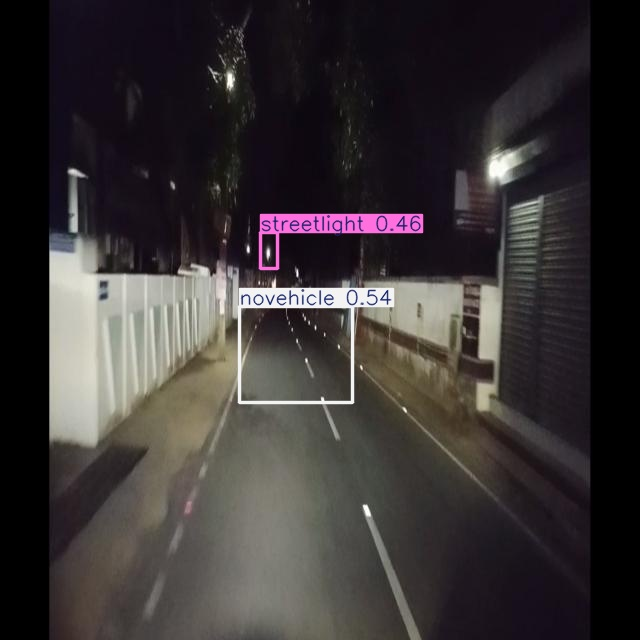

In [31]:
test_results = model.predict(source=os.path.join(base_path, 'test', 'images'), save=True, conf=0.25)

latest_predict_folder = max(glob('runs/detect/predict*'), key=os.path.getmtime)
predicted_images = glob(os.path.join(latest_predict_folder, '*.jpg'))[:3]

from IPython.display import Image, display
for img_path in predicted_images:
    display(Image(filename=img_path, width=400))

In [32]:
video_path = 'AI Scene.mp4'

if os.path.exists(video_path):
    model.predict(source=video_path, save=True, conf=0.40)